# YZ50 — Week 4: Activations, Gradients & BatchNorm

* After building the MLP language model, the focus shifts to understanding **what happens inside the network during training** by examining its activations and gradients.

* **Tanh saturation** occurs when activations approach -1 or 1, causing the gradients to become very small and making learning difficult.

* **Weight initialization** determines the initial scale of activations. **Kaiming initialization** helps keep the initial pre-activation values at an appropriate scale, reducing excessive **tanh saturation** and helping maintain useful gradients.

* **BatchNorm (Batch Normalization)** normalizes hidden-layer activations using statistics from each minibatch during training, helping stabilize the network and improve optimization.

* The same MLP is also trained on the **Turkish name dataset** from the previous week to examine how the model performs on Turkish character sequences.

In this part, I analyze **activations and gradients**, investigate **tanh saturation**, apply **Kaiming initialization**, compare models with and without **BatchNorm**, and evaluate the model on **Turkish names**.


# Continuing to Build Makemore: A Deeper Look at Activations, Gradients & BatchNorm

# 5. Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster.

In [262]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [263]:
# read in all the words
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [264]:
len(words)

32033

In [265]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [266]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        # %80
Xdev, Ydev = build_dataset(words[n1:n2])    # %10
Xte, Yte = build_dataset(words[n2:])        # %10

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [267]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [268]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.9356
  20000/ 200000: 2.5331
  30000/ 200000: 2.9308
  40000/ 200000: 2.1004
  50000/ 200000: 2.4989
  60000/ 200000: 2.4067
  70000/ 200000: 2.1295
  80000/ 200000: 2.3477
  90000/ 200000: 2.3098
 100000/ 200000: 2.0809
 110000/ 200000: 2.3818
 120000/ 200000: 2.0194
 130000/ 200000: 2.4772
 140000/ 200000: 2.2544
 150000/ 200000: 2.1509
 160000/ 200000: 2.0979
 170000/ 200000: 1.8214
 180000/ 200000: 1.9808
 190000/ 200000: 1.8395


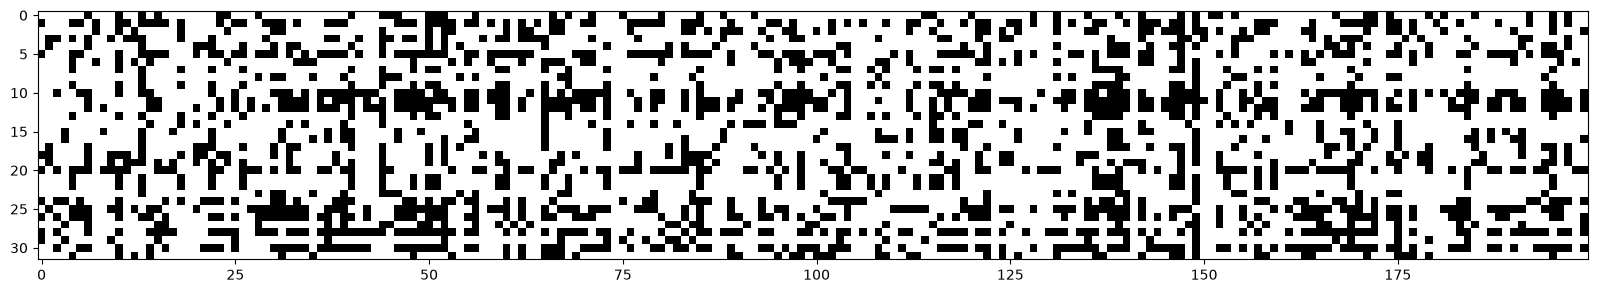

In [269]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

### Activation Saturation

Each **column** represents a neuron, while each **row** represents an example. Therefore, each cell shows the activation value of a specific neuron for a specific example.

The white cells indicate neurons whose activation is very high in magnitude (`|h| > 0.99`), meaning they are operating near the saturation region of `tanh`.

If an entire column is white, that neuron is **dead**: it is saturated for every example, receives almost no gradient, and therefore **cannot effectively learn**.

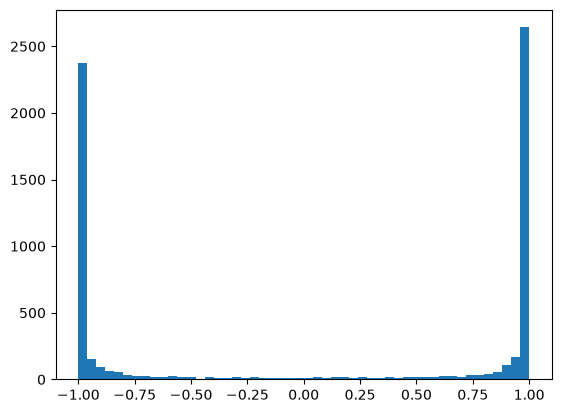

In [270]:
plt.hist(h.view(-1).tolist(),50);

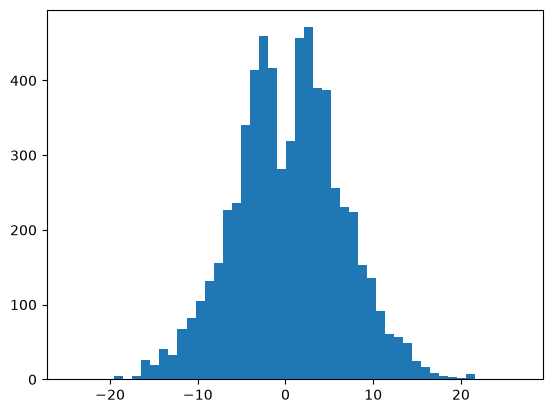

In [271]:
plt.hist(hpreact.view(-1).tolist(),50);

## 2.nd Problem Tanh Activation Distribution

<div align="center">
    <img src="../images/tanh.png" width="750">
</div>

After applying `tanh`, the activations are limited to the range `[-1, 1]`. However, in this case, most activations are concentrated very close to **-1 and +1**.

This is problematic because `tanh` **saturates** at its extremes.

The derivative of `tanh` is:

```python
tanh'(x) = 1 - tanh(x)**2

When the activation is close to -1 or +1:

self.grad = tanh'(x) * out.grad

tanh(x) ≈ ±1
        ↓
1 - tanh(x)² ≈ 0

So during backpropagation, the gradient gets multiplied by a value close to zero:

gradient
   ↓
× tanh'(x)
   ↓
× ~0
   ↓
very small gradient

This causes the vanishing gradient problem. The gradients flowing back through the tanh layer become very small, so earlier layers receive very little information about how their weights should change.

As a result:

Earlier layers learn very slowly.
Training becomes less efficient.
The network can have difficulty improving its parameters.

Ideally, we want the pre-activations to be mostly around the linear region of tanh, near 0.

Around zero:

tanh(0) = 0
tanh'(0) = 1

This allows gradients to pass through effectively.

In short: The problem is not that tanh outputs values in [-1, 1]. The problem is that too many activations are near -1 or +1, where tanh saturates and its derivative becomes almost zero, causing gradients to vanish during backpropagation.

### ReLU and Zero Gradients

<div align="center">
    <img src="../images/Relu.png" width="750">
</div>

The ReLU activation function is defined as:

$$
\text{ReLU}(x) = \max(0, x)
$$

Its derivative is:

$$
\text{ReLU}'(x) =
\begin{cases}
0 & x < 0 \\
1 & x > 0
\end{cases}
$$

When the pre-activation value is negative, the ReLU output is `0`, so:

$$
\text{gradient} = \text{ReLU}'(x) \cdot out.grad
= 0 \cdot out.grad = 0
$$

Therefore, the neuron receives **no gradient and cannot update its parameters**. If it remains negative, it becomes a **dead ReLU neuron** and cannot learn.

Unlike `tanh`, where the gradient becomes **very small** near saturation, ReLU has a gradient that is **exactly zero** for negative inputs.

### Both **tanh saturation** (gradients approaching zero) and **ReLU dead neurons** (gradients becoming exactly zero) can occur due to **random initialization** or during **optimization** as the model's parameters are updated.

Once a neuron becomes dead, if **no example activates it again**, it receives no gradient, its parameters are never updated, and the **neuron remains dead forever** — essentially, **permanent brain damage in a neural network**.

Unlike ReLU, **Leaky ReLU** maintain a non-zero gradient for negative inputs, so they **do not suffer from the dead neuron problem in the same way**.

## Solution for the 2nd Problem: Why We Initialize `W1` and `b1` This Way

```python
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
torch.nn.init.kaiming_normal_(W1, nonlinearity='tanh')
b1 = torch.randn(n_hidden, generator=g) * 0.01
```

We initialize `W1` using **Kaiming initialization** to choose an appropriate weight scale based on the input size (`n_embd * block_size`). This helps keep the pre-activation values at a reasonable scale and prevents `tanh` from becoming saturated, where gradients become very small.

The scale of the weights is therefore **not arbitrary**. Kaiming initialization determines it based on the layer's input dimensionality and the chosen nonlinearity.

For `b1`, we use small random values close to zero. This prevents the biases from unnecessarily shifting the pre-activations into the saturated regions of `tanh`.

> **In short:** Kaiming initialization gives `W1` an appropriate scale based on the input size, while `b1 ≈ 0` prevents unnecessary shifts and helps keep `tanh` in a useful range.


In [272]:
# This is the loss that we would expect if we were to guess each character uniformly at random. It is used as a baseline to compare the model's performance against random guessing.
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [273]:
# 4-dimensional example of the issue
#logits = torch.tensor([-3.0, 5.0, 0.0, 2.0])
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([ 18.9660,   0.6254,  -3.7565, -12.3813]),
 tensor([1.0000e+00, 1.0835e-08, 1.3544e-10, 2.4324e-14]),
 tensor(22.7225))

## 1.th Problem Why the Loss Changes Randomly

The logits are randomly sampled using `torch.randn(4)`, which produces values from a standard normal distribution. Multiplying them by `10` makes the logits much larger in magnitude.

Because `softmax` is very sensitive to differences between large logits, small changes in the randomly generated logits can cause the probability distribution to change drastically.

Here, the loss is calculated for the class at **index 2**:

```python
loss = -probs[2].log()
```

If the random logits give a high value to index 2, `probs[2]` becomes large and the loss is small. However, if another index gets a much larger logit than index 2, most of the probability is assigned to that other class, making `probs[2]` very small and the loss very large.

In short:

> **Random logits + scaling by 10 → large logit differences → highly concentrated softmax probabilities → randomly very small or very large loss.**

### Desired Initialization

When the network is initialized, we generally want the logits to be roughly around zero rather than having very large positive or negative values. This keeps the initial softmax probabilities relatively balanced and prevents the model from starting with an overly confident prediction.

## Solution for 1.th Problem Why We Initialize `W2` and `b2` This Way

```python
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
```

We initialize `W2` with small random values (`* 0.01`) so that the initial logits remain **close to zero**. This prevents the softmax from becoming overly confident at initialization and helps keep the initial loss relatively low and stable.

We **do not initialize `W2` to exactly zero** because that would make all output neurons behave identically. Since every output neuron would receive the same weights, they would produce the same gradients and remain symmetric during training.

Instead, using small random values breaks this symmetry while keeping the initial logits close to zero.

For `b2`, multiplying by `0` makes all biases exactly zero. This is fine because biases do not suffer from the same symmetry problem as weights. The small random values in `W2` are enough to break the symmetry between output neurons.

> **In short:** `W2 ≈ 0` keeps the initial logits small, while random values prevent all output neurons from learning the exact same thing.


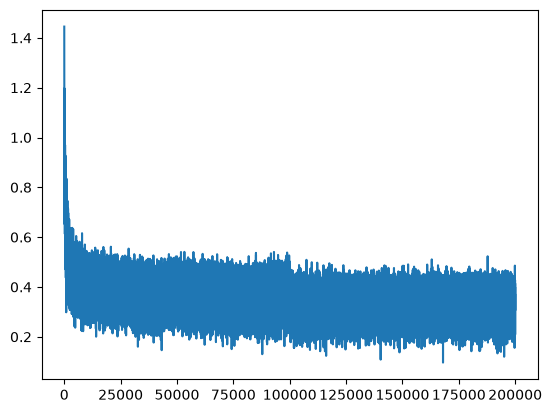

In [274]:
plt.plot(lossi)

In [275]:
@torch.no_grad() # this decorator disables gradient tracking
# This function computes the loss on a given split of the data (train, val, or test) without tracking gradients. It retrieves the appropriate input and target tensors based on the specified split, performs a forward pass through the model, computes the logits, and calculates the cross-entropy loss. Finally, it prints the loss value for the specified split.
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1265742778778076
val 2.170107841491699


In [276]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carlah.
amori.
kahlin.
shreety.
skanden.
jazonen.
den.
art.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quint.
salin.
alianni.
wazelo.
dearynix.
kaeliighan.


### Reinitialize the network after applying solutions

In [277]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) #* (5/3) / (n_embd * block_size)**0.5
torch.nn.init.kaiming_normal_(W1, nonlinearity='tanh') # initialize the weights of the first layer using Kaiming normal initialization, normally used for ReLU activations, but can also be used for tanh activations. This helps in maintaining the variance of the activations across layers, which can lead to better convergence during training.
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


## Calculating the init scale - Kaiming init

### Why Kaiming Initialization Matters

Kaiming initialization is used to choose suitable initial weight values so that the **variance of activations remains well-scaled as they pass through the network**. This helps prevent activations from becoming excessively large or too small, which can lead to **saturation and vanishing gradients**, especially when using nonlinear activation functions such as `tanh`.

In our case, Kaiming initialization is applied to `W1` to provide a more appropriate starting point for the weights instead of manually choosing a scaling factor.

A good **forward pass** is important because the values produced during the forward pass directly determine the gradients calculated during the **backward pass**. In other words, the better behaved the forward pass is, the more stable and effective the backward pass can be.

**Good forward pass → meaningful gradients → effective learning.**


In [278]:
# Buildin kaiming initialization function can be used to initialize the weights of the first layer (W1) in a way that is suitable for the tanh activation function. This helps in maintaining the variance of the activations across layers, which can lead to better convergence during training.

# torch.nn.init.kaiming_normal_(W1, nonlinearity='tanh')

tensor(0.0030) tensor(0.9923)
tensor(0.0016) tensor(0.9655)


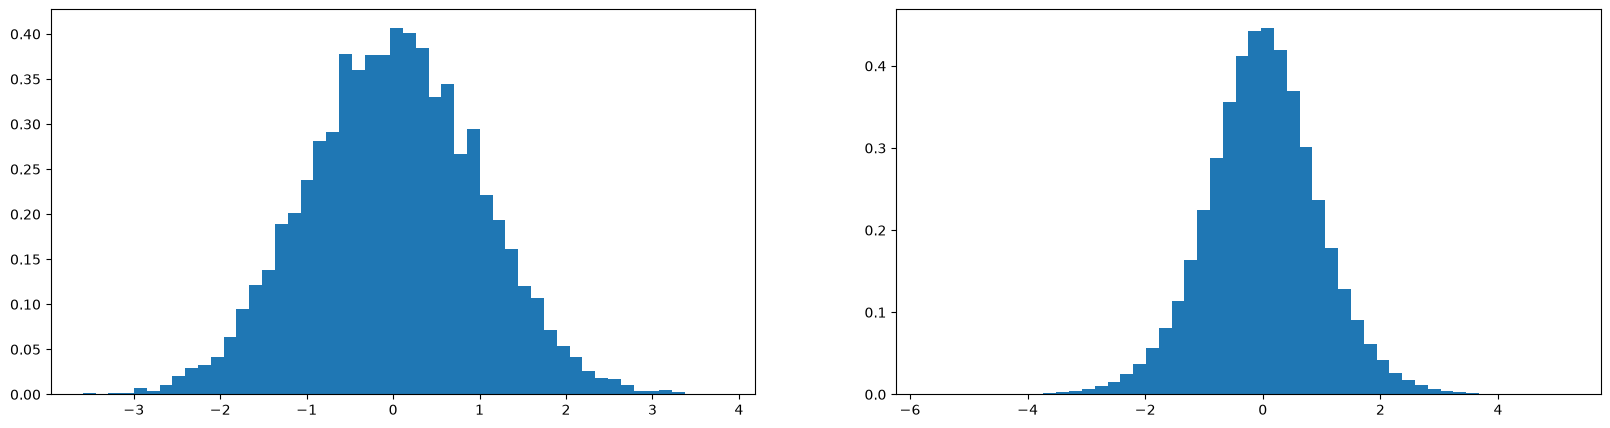

In [279]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 # devide by square root of fan-in to keep variance of y similar to x
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [280]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2827
  10000/ 200000: 2.1157
  20000/ 200000: 2.3026
  30000/ 200000: 2.5617
  40000/ 200000: 1.9033
  50000/ 200000: 2.4963
  60000/ 200000: 2.3884
  70000/ 200000: 2.1138
  80000/ 200000: 2.1414
  90000/ 200000: 2.1201
 100000/ 200000: 1.7537
 110000/ 200000: 2.1326
 120000/ 200000: 1.8315
 130000/ 200000: 2.4417
 140000/ 200000: 2.3771
 150000/ 200000: 2.1636
 160000/ 200000: 1.8389
 170000/ 200000: 1.7842
 180000/ 200000: 1.9881
 190000/ 200000: 1.7658


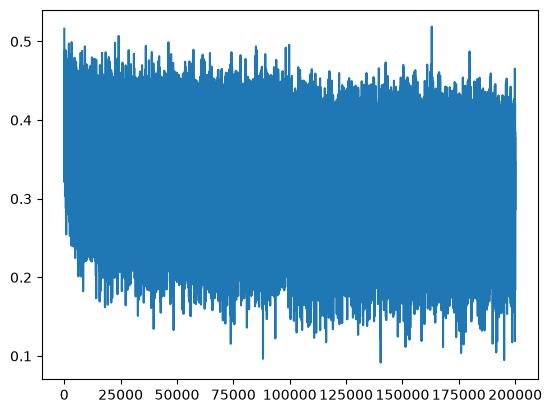

In [281]:
plt.plot(lossi)

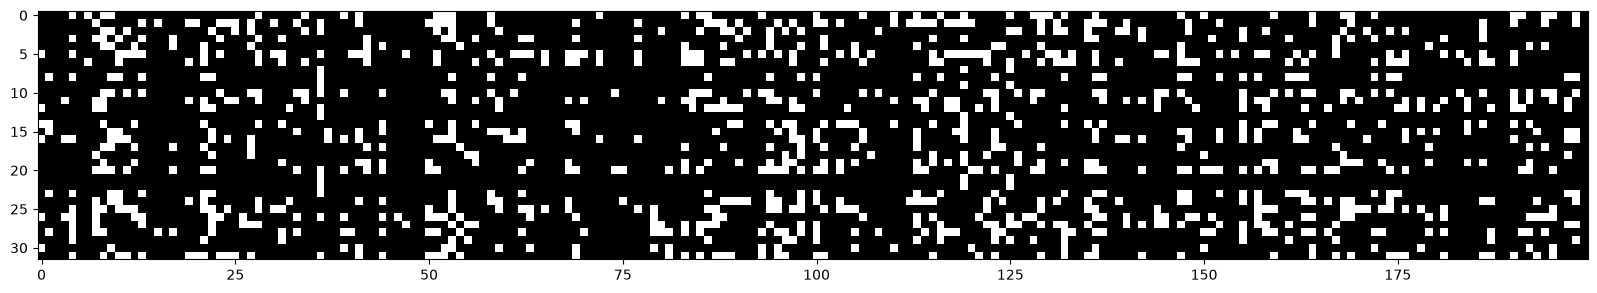

In [282]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

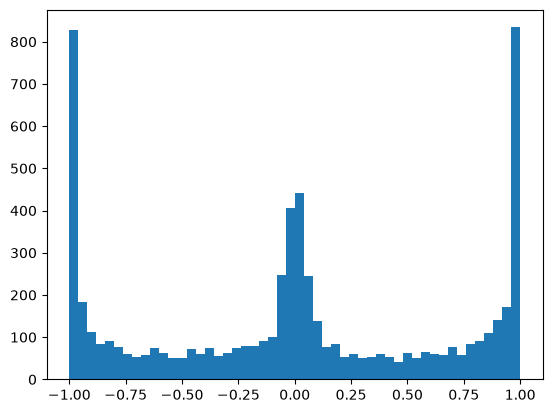

In [283]:
plt.hist(h.view(-1).tolist(),50);

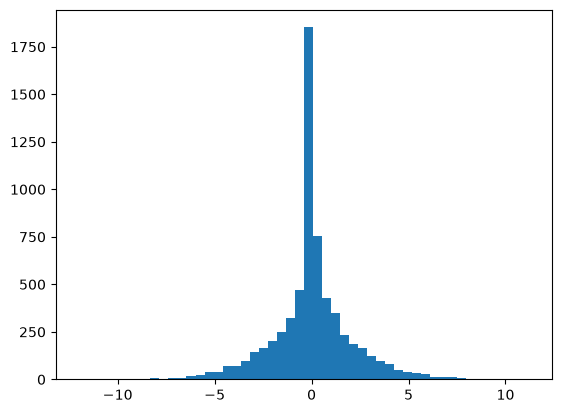

In [284]:
plt.hist(hpreact.view(-1).tolist(),50);

In [285]:
split_loss('train')
split_loss('val') # dev

train 2.052079200744629
val 2.1076486110687256


In [286]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
amelle.
khy.
milia.
atlannah.
sae.
mahni.
faresara.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jocn.
quint.
salin.
alianni.
wavero.
dearyxia.
kaellissa.


# 6. BatchNorm katmanını gizli katmandan sonra ekle. Eğitim sırasında batch istatistiği, tahmin sırasında running mean kullan. BatchNorm'lu ve BatchNorm'suz modelin dev loss'unu karşılaştır.

### Batch Normalization

We use **Batch Normalization (BatchNorm)** to control the **statistics of activations** in a neural network. The main idea is to prevent the activations produced by a layer from becoming **too large, too small, or poorly distributed** during training.

As the weights of the network change during optimization, the distribution of the activations can also change. BatchNorm keeps these activations at a more **stable and well-scaled range** by normalizing them using their mean and standard deviation.

This is especially useful before nonlinear activation functions such as `tanh`. If the inputs to `tanh` become too large in magnitude, the activation can enter its **saturation regions**, where the gradients become very small. By keeping the pre-activations better behaved, BatchNorm can help maintain more useful gradients and make the network **easier and more stable to optimize**.

In short, the purpose of BatchNorm is to **keep the activations well-behaved during training**, so that the network can propagate information and gradients more effectively.

---

It is common to apply BatchNorm after layers that perform multiplications, such as **linear layers** or **convolutional layers**. In our case, we apply it to the hidden layer **pre-activations** produced by:

$$
h_{preact} = XW_1 + b1
$$

Instead of directly passing these values to `tanh`, we normalize them across the mini-batch:

$$
\hat{h} = \frac{h_{preact} - \mu_B}{\sigma_B + \epsilon}
$$

and then apply a learnable scale and shift:

$$
h_{preact} = \hat{h} \cdot \gamma + \beta
$$

Although normalization keeps the pre-activations around **mean 0 and standard deviation 1**, we do not want to force the network to always operate under this fixed distribution. The network may benefit from a different scale or center for each feature.

Therefore, BatchNorm introduces two **learnable parameters**:

- **Scale:** $\gamma$ controls the scale of the normalized activations.

- **Shift:** $\beta$ controls the center of the normalized activations.

This gives the network the flexibility to learn the most useful distribution during training, while still benefiting from the more stable activations provided by normalization. In other words, normalization helps prevent activations from unnecessarily entering the saturation regions of functions such as `tanh`, while \(\gamma\) and \(\beta\) allow the model to adjust the normalized values when a different scale or center is more useful.


---
### BatchNorm and the Bias Term

Because BatchNorm subtracts the batch mean from `hpreact`, the bias term `b1` is canceled out during normalization:

$$
(embcatW_1 + b_1) - mean(embcatW_1 + b_1)
= embcatW_1 - mean(embcatW_1)
$$

Therefore, the original `b1` becomes **redundant** and can be removed.

Instead, BatchNorm uses the learnable parameter `bnbias` to apply a shift **after normalization**:

$$
\hat{h} = \frac{hpreact - bnmean}{bnstd + \epsilon}
$$

$$
h_{BN} = \hat{h} \cdot bngain + bnbias
$$

Thus, `bngain` controls the scale and `bnbias` controls the shift of the normalized activations, making the original `b1` unnecessary.

---

where:

* **`bngain` (`γ`)** is the learnable gain parameter.
* **`bnbias` (`β`)** is the learnable bias parameter.

These parameters are part of the model and are **trained using backpropagation**, just like the weights.

BatchNorm also maintains two **buffers**:

* **`bnmean_running`** — running mean of the batch means.
* **`bnstd_running`** — running standard deviation of the batch standard deviations.

Unlike `bngain` and `bnbias`, these buffers are **not trained using backpropagation**. They are updated using a running average during training:

$$
\text{running\_mean}
\leftarrow
0.999 \cdot \text{running\_mean}
+
0.001 \cdot \text{batch\_mean}
$$

The same idea is used for the running standard deviation.

During **training**, BatchNorm uses the statistics of the current mini-batch:

```python
bnmeani = hpreact.mean(0, keepdim=True)
bnstdi = hpreact.std(0, keepdim=True)
```

During **evaluation**, we no longer want the output to depend on the statistics of the current batch. Therefore, we use the accumulated **running mean and running standard deviation**:

```python
hpreact = (hpreact - bnmean_running) / (bnstd_running + 1e-5) * bngain + bnbias
```

This allows the hidden activations to remain **stable and consistently normalized** between training and evaluation.

In short:

**Linear layer → BatchNorm → tanh**

**Learnable parameters:** `bngain`, `bnbias` → updated by backpropagation

**Buffers:** `bnmean_running`, `bnstd_running` → updated using running statistics, not backpropagation


### Reinitialize the network after applying solutions

In [287]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) # * (5/3) / (n_embd * block_size)**0.5
torch.nn.init.kaiming_normal_(W1, nonlinearity='tanh') # initialize the weights of the first layer using Kaiming normal initialization, normally used for ReLU activations, but can also be used for tanh activations. This helps in maintaining the variance of the activations across layers, which can lead to better convergence during training.
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0


bngain = torch.ones((1, n_hidden)) # gain parameter for batch normalization
bnbias = torch.zeros((1, n_hidden)) # bias parameter for batch normalization
bnmean_running = torch.zeros((1, n_hidden)) # running mean for batch normalization
bnstd_running = torch.ones((1, n_hidden)) # running std for batch normalization

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [288]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors,

  # Linear layer pre-activation
  hpreact = embcat @ W1# + b1 # hidden layer pre-activation
  
  # Batch normalization later
  #-----------------------------------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = (hpreact - bnmeani) / (bnstdi + 1e-5) * bngain + bnbias # batch normalization

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  #-----------------------------------------------------------------------------------------
  
  # Nonlinearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3052


  10000/ 200000: 2.0255
  20000/ 200000: 2.5822
  30000/ 200000: 1.9998
  40000/ 200000: 2.2535
  50000/ 200000: 1.9210
  60000/ 200000: 2.0980
  70000/ 200000: 2.3137
  80000/ 200000: 2.3281
  90000/ 200000: 2.1225
 100000/ 200000: 2.2507
 110000/ 200000: 2.2795
 120000/ 200000: 1.6732
 130000/ 200000: 1.9357
 140000/ 200000: 2.1025
 150000/ 200000: 2.0023
 160000/ 200000: 2.0386
 170000/ 200000: 2.4548
 180000/ 200000: 2.0830
 190000/ 200000: 2.1786


In [289]:
# calibrate the batch norm at the end of training
"""
with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)
"""
# We are now doing this operation in the forward pass with the running mean and std, so we don't need to do it here anymore.

'\nwith torch.no_grad():\n  # pass the training set through\n  emb = C[Xtr]\n  embcat = emb.view(emb.shape[0], -1)\n  hpreact = embcat @ W1 + b1\n  # measure the mean/std over the entire training set\n  bnmean = hpreact.mean(0, keepdim=True)\n  bnstd = hpreact.std(0, keepdim=True)\n'

In [290]:
@torch.no_grad() # this decorator disables gradient tracking
# This function computes the loss on a given split of the data (train, val, or test) without tracking gradients. It retrieves the appropriate input and target tensors based on the specified split, performs a forward pass through the model, computes the logits, and calculates the cross-entropy loss. Finally, it prints the loss value for the specified split.
def split_loss_batchnorm(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1# + b1 # hidden layer pre-activation
  #hpreact = (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True) + 1e-5) * bngain + bnbias # batch normalization
  hpreact = (hpreact - bnmean_running) / (bnstd_running + 1e-5) * bngain + bnbias # batch normalization using the running mean and running standard deviation accumulated during training
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss_batchnorm('train')
split_loss_batchnorm('val')

train 2.0593910217285156
val 2.104926109313965


## Loss Comparison

| Configuration | Train Loss | Validation Loss |
|---|---:|---:|
| Initial Loss | 2.1265742778778076 | 2.170107841491699 |
| After Weight & Kaiming Initialization | 2.052079200744629 | 2.1076486110687256 |
| After Batch Normalization | 2.059391021728516 | 2.104926109313965 |

# 7. Geçen haftaki Türkçe isim listenle aynı modeli eğit. Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. Bigram'ın Türkçe sonuçlarıyla yan yana koy.

## 7.1 Create the lookup tables and Initialize the dataset

In [291]:
# read in all the words
words_tr = open('../data/isimler.txt', 'r', encoding='utf-8').read().splitlines()
words_tr[:8]

['JALE',
 'ALİ',
 'MAHMUT',
 'MANSUR KÜRŞAD',
 'GAMZE',
 'MİRAÇ',
 'YÜCEL',
 'KUBİLAY']

In [292]:
len(words_tr)

2446

In [293]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words_tr))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: ' ', 2: 'A', 3: 'B', 4: 'C', 5: 'D', 6: 'E', 7: 'F', 8: 'G', 9: 'H', 10: 'I', 11: 'J', 12: 'K', 13: 'L', 14: 'M', 15: 'N', 16: 'O', 17: 'P', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'Y', 24: 'Z', 25: 'Ç', 26: 'Ö', 27: 'Ü', 28: 'Ğ', 29: 'İ', 30: 'Ş', 0: '.'}
31


In [294]:
random.seed(42)
random.shuffle(words_tr)
n1 = int(0.8*len(words_tr))
n2 = int(0.9*len(words_tr))

Xtr, Ytr = build_dataset(words_tr[:n1])        # %80
Xdev, Ydev = build_dataset(words_tr[n1:n2])    # %10
Xte, Yte = build_dataset(words_tr[n2:])        # %10

torch.Size([14517, 3]) torch.Size([14517])
torch.Size([1806, 3]) torch.Size([1806])
torch.Size([1785, 3]) torch.Size([1785])


## 7.2 Initialize the Network

In [295]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) # * (5/3) / (n_embd * block_size)**0.5
torch.nn.init.kaiming_normal_(W1, nonlinearity='tanh') # initialize the weights of the first layer using Kaiming normal initialization, normally used for ReLU activations, but can also be used for tanh activations. This helps in maintaining the variance of the activations across layers, which can lead to better convergence during training.
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0


bngain = torch.ones((1, n_hidden)) # gain parameter for batch normalization
bnbias = torch.zeros((1, n_hidden)) # bias parameter for batch normalization
bnmean_running = torch.zeros((1, n_hidden)) # running mean for batch normalization
bnstd_running = torch.ones((1, n_hidden)) # running std for batch normalization

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12941


## 7.3 Neural Network Training Loop with Kaiming Initialization and Batch Normalization


In [296]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors,

  # Linear layer pre-activation
  hpreact = embcat @ W1# + b1 # hidden layer pre-activation
  
  # Batch normalization later
  #-----------------------------------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = (hpreact - bnmeani) / (bnstdi + 1e-5) * bngain + bnbias # batch normalization

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  #-----------------------------------------------------------------------------------------
  
  # Nonlinearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.4467


  10000/ 200000: 1.5406
  20000/ 200000: 1.6609
  30000/ 200000: 1.0941
  40000/ 200000: 1.6842
  50000/ 200000: 1.2085
  60000/ 200000: 1.2697
  70000/ 200000: 1.5482
  80000/ 200000: 1.1521
  90000/ 200000: 1.6026
 100000/ 200000: 1.4706
 110000/ 200000: 1.3719
 120000/ 200000: 1.0018
 130000/ 200000: 1.1137
 140000/ 200000: 1.5094
 150000/ 200000: 1.3912
 160000/ 200000: 0.7985
 170000/ 200000: 0.9959
 180000/ 200000: 1.1955
 190000/ 200000: 1.3417


## 7.4 Calculating loss

In [297]:
split_loss_batchnorm('train')
split_loss_batchnorm('val')

train 1.139387607574463
val 1.6155171394348145


## 7.5 Sample from the Trained Artificial Neural Network

In [298]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

model_names = []

for _ in range(30):
    
    out = []
    context = [0] * block_size # initialize with all ...

    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      hpreact = emb.view(1, -1) @ W1 # + b1 # hidden layer pre-activation
      hpreact = (hpreact - bnmean_running) / (bnstd_running + 1e-5) * bngain + bnbias # batch normalization using the running mean and running standard deviation accumulated during training
      h = torch.tanh(hpreact)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    name = ''.join(itos[i] for i in out)
    print(name) # decode and print the generated word
    model_names.append(name)

BURCU.
TUĞBA.
SEHEN.
HALEYMA.
FER.
TUĞBA.
MUSTAFA.
ERKERİM.
MUSTAFA KEMAL.
MEHMET DENİZİN.
AYSU.
ENVER.
MESUT.
RAHİM HASAN.
BURAK.
MUSTAFA ALİ.
UTKU.
EVRE.
MUMUT.
SELÇUK.
ŞENAY.
SEVİL.
MEHMET ARDAR.
ÖMERVE SERPİL.
MUHİ HALE.
BİNYAMİ.
BURAT.
ÇETİN.
SİBEL.
SERKAY.


## 7.6 Compare the Outputs with the Bigram Model

In [299]:
# Bigram model names
# ANN model names
bigram_names = [
    "BURAN", "H", "FA", "AN", "MA EP", "MAŞEN", "ZEMERARH",
    "ER", "SETULİNE", "BAHAT", "AHİK", "BR", "ÇİNCE", "YDULAMHATU",
    "TUNETMERE", "SET", "MZGE", "SE MRCİT", "A", "TM",
    "AŞABAMURKERULAT", "BİRAYGÜLAKARANEMUA", "MATİZER", "Ç CİLL",
    "EYZUNUAYFAHMİRSA", "T", "FALIN", "TİN", "ÖZİZİNDE", "ÜL"
]

# Comparison table
df = pd.DataFrame({
    "Neural Network": model_names,
    "Bigram": bigram_names
})

df

,Neural Network,Bigram
0,BURCU.,BURAN
1,TUĞBA.,H
2,SEHEN.,FA
3,HALEYMA.,AN
4,FER.,MA EP
5,TUĞBA.,MAŞEN
6,MUSTAFA.,ZEMERARH
7,ERKERİM.,ER
8,MUSTAFA KEMAL.,SETULİNE
9,MEHMET DENİZİN.,BAHAT
